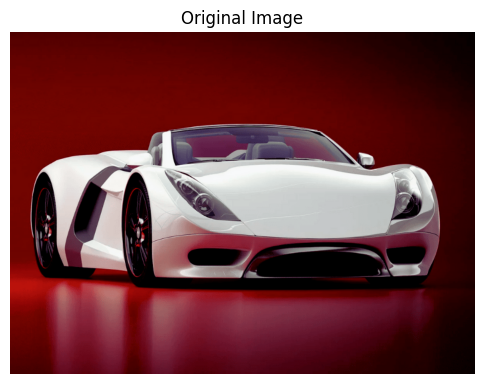

In [3]:
# ==========================================
# Module 12 - Histograms
# Complete Example
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# Read Image
# ------------------------------------------

image_path = r"E:\Open CV\Module 12 - Histograms\Images\sample.png"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not found!")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ------------------------------------------
# Display Original Image
# ------------------------------------------

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()



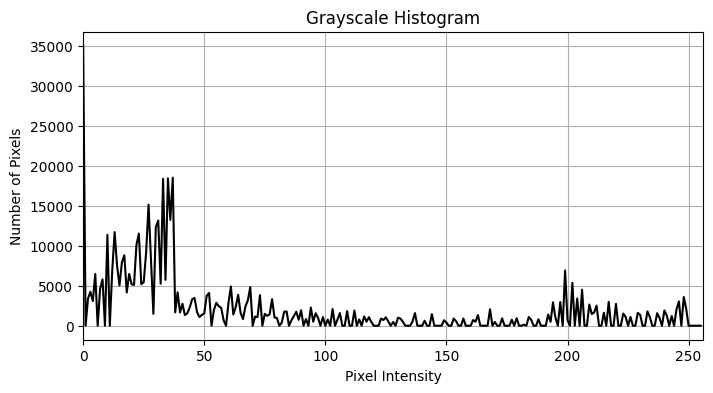

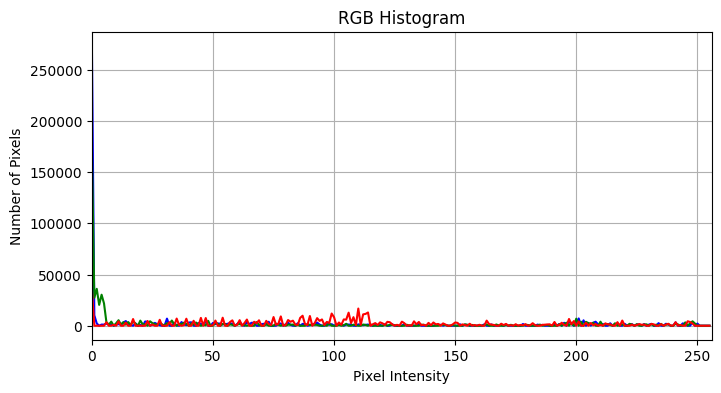

In [4]:
# ==========================================
# 1. Histogram
# ==========================================

hist = cv2.calcHist([gray], [0], None, [256], [0,256])

plt.figure(figsize=(8,4))
plt.plot(hist, color="black")
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0,256])
plt.grid()
plt.show()

# ==========================================
# RGB Histogram
# ==========================================

colors = ("b", "g", "r")

plt.figure(figsize=(8,4))

for i, color in enumerate(colors):

    hist = cv2.calcHist([image], [i], None, [256], [0,256])

    plt.plot(hist, color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0,256])
plt.grid()
plt.show()



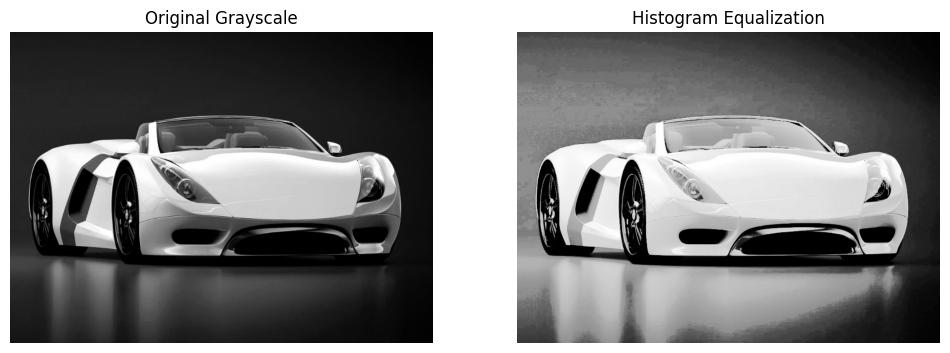

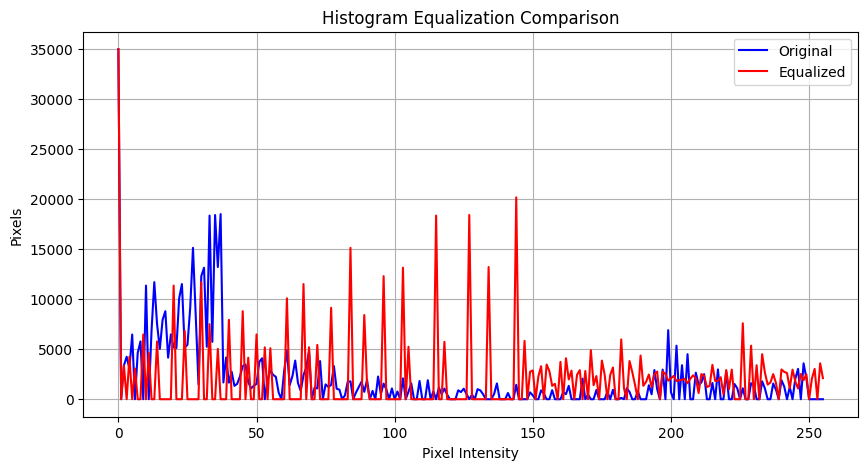

In [5]:
# ==========================================
# 2. Histogram Equalization
# ==========================================

equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()

# Histogram Before & After Equalization

hist_original = cv2.calcHist([gray],[0],None,[256],[0,256])
hist_equalized = cv2.calcHist([equalized],[0],None,[256],[0,256])

plt.figure(figsize=(10,5))

plt.plot(hist_original, color="blue", label="Original")
plt.plot(hist_equalized, color="red", label="Equalized")

plt.title("Histogram Equalization Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixels")

plt.legend()
plt.grid()
plt.show()



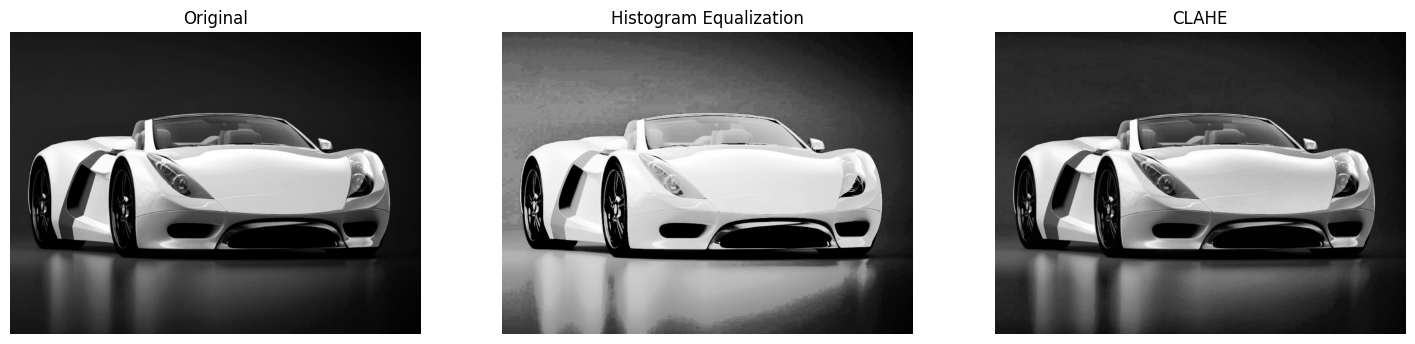

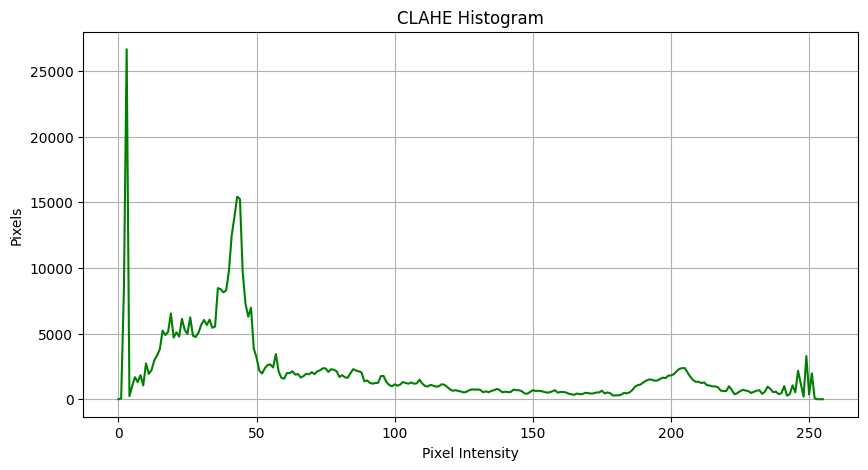

In [6]:
# ==========================================
# 3. CLAHE
# ==========================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

clahe_image = clahe.apply(gray)

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.show()

# ==========================================
# CLAHE Histogram
# ==========================================

hist_clahe = cv2.calcHist([clahe_image],[0],None,[256],[0,256])

plt.figure(figsize=(10,5))

plt.plot(hist_clahe, color="green")

plt.title("CLAHE Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixels")
plt.grid()

plt.show()



Histogram Comparison Results
Correlation      : 0.9261
Chi-Square       : 1.4984
Intersection     : 6.4436
Bhattacharyya    : 0.3036


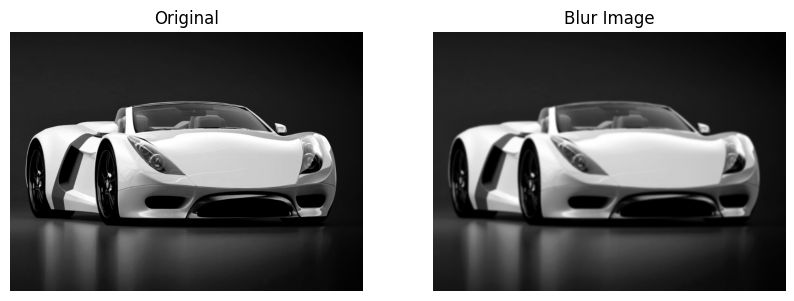

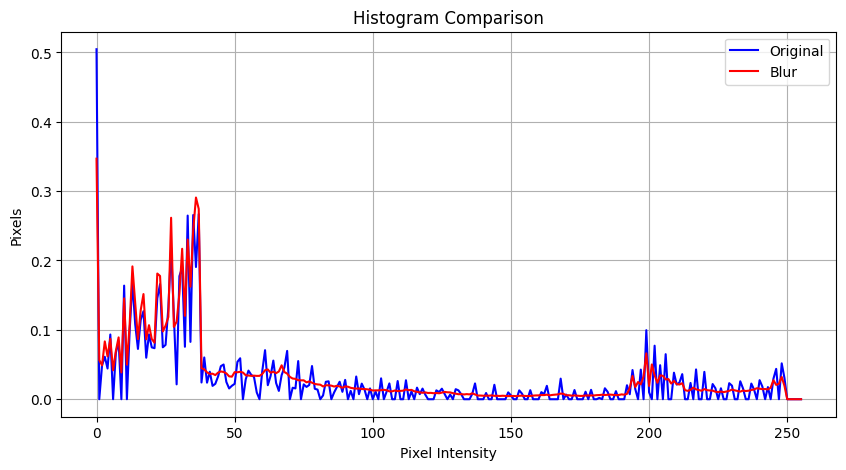

In [7]:
# ==========================================
# 4. Histogram Comparison
# ==========================================

# Create a modified image
blur = cv2.GaussianBlur(gray, (9,9), 0)

# Calculate Histograms

hist1 = cv2.calcHist([gray],[0],None,[256],[0,256])
hist2 = cv2.calcHist([blur],[0],None,[256],[0,256])

# Normalize Histograms

cv2.normalize(hist1, hist1)
cv2.normalize(hist2, hist2)

# Compare

correlation = cv2.compareHist(
    hist1,
    hist2,
    cv2.HISTCMP_CORREL
)

chi_square = cv2.compareHist(
    hist1,
    hist2,
    cv2.HISTCMP_CHISQR
)

intersection = cv2.compareHist(
    hist1,
    hist2,
    cv2.HISTCMP_INTERSECT
)

bhattacharyya = cv2.compareHist(
    hist1,
    hist2,
    cv2.HISTCMP_BHATTACHARYYA
)

print("="*50)
print("Histogram Comparison Results")
print("="*50)

print(f"Correlation      : {correlation:.4f}")
print(f"Chi-Square       : {chi_square:.4f}")
print(f"Intersection     : {intersection:.4f}")
print(f"Bhattacharyya    : {bhattacharyya:.4f}")

# ==========================================
# Display Images Used for Comparison
# ==========================================

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Blur Image")
plt.axis("off")

plt.show()

# ==========================================
# Plot Both Histograms
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(hist1, color="blue", label="Original")
plt.plot(hist2, color="red", label="Blur")

plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixels")

plt.legend()
plt.grid()

plt.show()